In [1]:
import pandas as pd
import numpy as np
import math
import xgboost
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, PredefinedSplit
from hypopt import GridSearch
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/raw/train.csv")
#df.dropna(inplace=True)
y_label = 'Survived'
#columns_to_remove = ['Name', 'PassengerId']
columns_to_remove = ['PassengerId', 'Ticket']
df.drop(columns=columns_to_remove, inplace=True)
df['Cabin'].fillna('mising', inplace=True)
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode(), inplace=True)
df.dropna(inplace=True)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,7.2500,mising,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,7.9250,mising,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,8.0500,mising,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,13.0000,mising,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,23.4500,mising,S
889,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,30.0000,C148,C


In [2]:
#ctg_columns = ['Sex', 'Ticket', 'Cabin', 'Embarked']
ctg_columns = ['Embarked', 'Cabin']
num_columns = list(set(df.columns) - set(ctg_columns) - set(y_label))

nd_title = [i.split(",")[1].split(".")[0].strip() for i in df["Name"]]
df["Title"] = pd.Series(nd_title)
df["Title"] = df["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', math.nan], 'Rare')
df["Title"] = df["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
df["Title"] = df["Title"].astype(int)
df["Fsize"] = df["SibSp"] + df["Parch"] + 1
df['Single'] = df['Fsize'].map(lambda s: 1 if s == 1 else 0)
df['SmallF'] = df['Fsize'].map(lambda s: 1 if  s == 2  else 0)
df['MedF'] = df['Fsize'].map(lambda s: 1 if 3 <= s <= 4 else 0)
df['LargeF'] = df['Fsize'].map(lambda s: 1 if s >= 5 else 0)
df.drop(columns=['Name'], inplace=True)

# Create new feature IsAlone from FamilySize
df['IsAlone'] = 0
df.loc[df['Fsize'] == 1, 'IsAlone'] = 1
# Create new feature CategoricalFare
df['CategoricalFare'] = pd.qcut(df['Fare'], 4)
df.loc[df['Fare'] <= 7.91, 'Fare'] = 0
df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.454), 'Fare'] = 1
df.loc[(df['Fare'] > 14.454) & (df['Fare'] <= 31), 'Fare']   = 2
df.loc[df['Fare'] > 31, 'Fare'] = 3
df['Fare'] = df['Fare'].astype(int)
df['Sex'] = df['Sex'].map( {'female': 0, 'male': 1} ).astype(int)
# Create new feature CategoricalAge
df['CategoricalAge'] = pd.cut(df['Age'], 5)
df.loc[df['Age'] <= 16, 'Age'] = 0
df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
df.loc[df['Age'] > 64, 'Age'] = 4 
df.drop(columns=['CategoricalAge', 'CategoricalFare'], inplace=True)
df_clean = df.copy(deep=True)

In [3]:
y_label = 'Survived'
df_train = pd.get_dummies(df, columns=ctg_columns)

y_train = df_train[y_label]
num_columns = ['Pclass', 'Age', 'Sex', 'SibSp', 'Parch', 'Fare' 'Title', 'Fsize', 'Single', 'SmallF', 'MedF', 'LargeF', 'IsAlone']
num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

column_to_nmlz = list(set(df_train.columns) - set([y_label]))
#df_train[column_to_nmlz] = num_pipeline.fit_transform(df_train[column_to_nmlz])
df_train[column_to_nmlz] = num_pipeline.fit_transform(df_train[column_to_nmlz])

train_set_normed, test_set_normed = train_test_split(df_train, test_size=0.2, random_state=42, stratify=y_train)
x_training_normed = train_set_normed.drop(columns=[y_label], axis=1)
x_test_normed = test_set_normed.drop(columns=[y_label], axis=1)
y_training_normed = train_set_normed[y_label]
y_test_normed = test_set_normed[y_label]
df_train_normed = df_train.drop(columns=[y_label])
y_all = df_train[y_label]
df_train_normed

,Pclass,Sex,Age,SibSp,Parch,Fare,Title,Fsize,Single,SmallF,...,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising
0,0.825209,0.735342,-0.355204,0.431350,-0.474326,-1.344968,0.655946,0.057853,-1.229349,2.126438,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,0.542247
1,-1.572211,-1.359911,0.878298,0.431350,-0.474326,1.341946,-0.954926,0.057853,-1.229349,2.126438,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,-1.844177
2,0.825209,-1.359911,-0.355204,-0.475199,-0.474326,-0.449330,-0.954926,-0.561804,0.813439,-0.470270,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,0.542247
3,-1.572211,-1.359911,0.878298,0.431350,-0.474326,1.341946,-0.954926,0.057853,-1.229349,2.126438,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,-1.844177
4,0.825209,0.735342,0.878298,-0.475199,-0.474326,-0.449330,0.655946,-0.561804,0.813439,-0.470270,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,0.542247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,-0.373501,0.735342,-0.355204,-0.475199,-0.474326,-0.449330,-0.954926,-0.561804,0.813439,-0.470270,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,0.542247
887,-1.572211,-1.359911,-0.355204,-0.475199,-0.474326,0.446308,0.655946,-0.561804,0.813439,-0.470270,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,-1.844177
888,0.825209,-1.359911,-0.355204,0.431350,2.006119,0.446308,0.655946,1.297169,-1.229349,-0.470270,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,0.542247
889,-1.572211,0.735342,-0.355204,-0.475199,-0.474326,0.446308,2.266818,-0.561804,0.813439,-0.470270,...,-0.033558,-0.033558,-0.047485,-0.058189,-0.058189,-0.033558,-0.047485,-0.067229,-0.033558,-1.844177


In [4]:
y_train = df_clean[y_label]
df_clean = pd.get_dummies(df_clean, columns=ctg_columns)

clean_train_set, clean_test_set = train_test_split(df_clean, test_size=0.2, random_state=42)
clean_x_training = clean_train_set.drop(columns=[y_label], axis=1)
clean_x_test = clean_test_set.drop(columns=[y_label], axis=1)
clean_y_training = clean_train_set[y_label]
clean_y_test = clean_test_set[y_label]
clean_x_training

df_clean_all = df_clean.drop(columns=[y_label])
y_all = df_clean[y_label]
df_clean_all

,Pclass,Sex,Age,SibSp,Parch,Fare,Title,Fsize,Single,SmallF,...,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising
0,3,1,1.0,1,0,0,2,2,0,1,...,0,0,0,0,0,0,0,0,0,1
1,1,0,2.0,1,0,3,1,2,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,0,1.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,2.0,1,0,3,1,2,0,1,...,0,0,0,0,0,0,0,0,0,0
4,3,1,2.0,0,0,1,2,1,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,1,1.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1
887,1,0,1.0,0,0,2,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0
888,3,0,1.0,1,2,2,2,4,0,0,...,0,0,0,0,0,0,0,0,0,1
889,1,1,1.0,0,0,2,3,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
def get_prediction_precision(model, testing_data, testing_labels):
    y_pred = model.predict(testing_data)
    n_correct = sum(y_pred == testing_labels)
    print("n_correct:{}".format(n_correct))
    print("accuracy: {}".format(float(n_correct) / len(y_pred)))

In [154]:
df_test = pd.read_csv("../data/raw/test.csv")
df_test['Cabin'].fillna('mising', inplace=True)
df_test['Age'].fillna(df['Age'].mean(), inplace=True)
df_test['Fare'].fillna(df['Fare'].mean(), inplace=True)

test_final_columns = list(df_train.columns)
test_final_columns.remove(y_label)
df_test_dummy = pd.DataFrame(columns=test_final_columns)
for idx, row in df_test.iterrows():
    series_dict = {}
    for col in test_final_columns:
        if '_' in col:
            ctg_name, ctg_value = col.split('_')
            series_dict[col] = 1 if row[ctg_name] == ctg_value else 0
        else:
            series_dict[col] = row[col]
    df_test_dummy= df_test_dummy.append(series_dict, ignore_index=True)
df_test_dummy

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Ticket_110152,Ticket_110413,Ticket_110465,...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising,Embarked_C,Embarked_Q,Embarked_S
0,3.0,34.500000,0.0,0.0,7.8292,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,3.0,47.000000,1.0,0.0,7.0000,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2.0,62.000000,0.0,0.0,9.6875,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3.0,27.000000,0.0,0.0,8.6625,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,3.0,22.000000,1.0,1.0,12.2875,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3.0,29.653446,0.0,0.0,8.0500,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
414,1.0,39.000000,0.0,0.0,108.9000,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
415,3.0,38.500000,0.0,0.0,7.2500,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
416,3.0,29.653446,0.0,0.0,8.0500,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [155]:
df_test_dummy[column_to_nmlz] = num_pipeline.fit_transform(df_test_dummy[column_to_nmlz])
df_test_dummy

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Ticket_110152,Ticket_110413,Ticket_110465,...,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising,Embarked_C,Embarked_Q,Embarked_S
0,0.873482,0.345019,-0.499470,-0.400248,-0.498253,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,2.843757,-1.350676
1,0.873482,1.335362,0.616992,-0.400248,-0.513120,1.322876,-1.322876,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
2,-0.315819,2.523773,-0.499470,-0.400248,-0.464935,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,2.843757,-1.350676
3,0.873482,-0.249187,-0.499470,-0.400248,-0.483313,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
4,0.873482,-0.645324,0.616992,0.619896,-0.418318,1.322876,-1.322876,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.873482,-0.038961,-0.499470,-0.400248,-0.494294,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
414,-1.505120,0.701542,-0.499470,-0.400248,1.313898,1.322876,-1.322876,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,-1.895628,1.760125,-0.351647,-1.350676
415,0.873482,0.661929,-0.499470,-0.400248,-0.508638,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370
416,0.873482,-0.038961,-0.499470,-0.400248,-0.494294,-0.755929,0.755929,0.0,0.0,0.0,...,-0.04897,-0.04897,0.0,-0.069338,-0.04897,0.0,0.527530,-0.568142,-0.351647,0.740370


Random Forest

In [133]:
def dict_product(d):
    keys = d.keys()
    for element in product(*d.values()):
        yield dict(zip(keys, element))

def GridSearchWithVal(model_class, param_grid, sub_class=None, sub_param_grid=None):
    combinations = list(dict_product(param_grid))
    best_acc = 0
    best_comb, best_model = None, None
    best_sub_comb = None
    print("{} combinations in total".format(len(combinations)))
    for comb in combinations:
        print(comb)
        
        if sub_class is None:
            model = model_class(**comb)
            model.fit(x_training_normed, y_training_normed)
            #model.fit(clean_x_training, clean_y_training)
            y_pred = model.predict(x_test_normed)
            #y_pred = model.predict(clean_x_test)
            n_correct = sum(y_pred == y_test_normed)
            #n_correct = sum(y_pred == clean_y_test)
            acc = float(n_correct) / len(y_pred)
            if acc > best_acc:
                best_acc = acc
                best_comb = comb
                best_model = model
        else:
            sub_combinations = list(dict_product(sub_param_grid))
            for sub_comb in sub_combinations:
                estimator = sub_class(**sub_comb)
                model = model_class(estimator, **comb)
                #model.fit(X_training, y_training)
                model.fit(clean_x_training, clean_y_training)
                #y_pred = model.predict(X_test)
                y_pred = model.predict(clean_x_test)
                #n_correct = sum(y_pred == y_test)
                n_correct = sum(y_pred == clean_y_test)
                acc = float(n_correct) / len(y_pred)
                if acc > best_acc:
                    best_acc = acc
                    best_comb = comb
                    best_model = model
                    best_sub_comb = sub_comb
        
    print("best params:{}".format(best_comb))   
    if best_sub_comb is not None:
        print("best_sub_comb:{}".format(best_sub_comb))
    print("best acc:{}".format(best_acc))
    return best_comb, best_sub_comb

In [43]:
rf_param_grid = {"n_estimators" : [150, 200, 250, 300, 250],
                  "criterion" : ["entropy"],
                  "max_depth": [4, 5, 6, 7, None],
                  "max_features": [None],
                  "min_samples_split": [2, 3],
                  "min_samples_leaf": [1, 3],
                  "bootstrap": [True, False]
                 }
rfc_best_comb, _ = GridSearchWithVal(RandomForestClassifier, rf_param_grid)

480 combinations in total
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 

{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_sample

{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'auto', 'min_

{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_sa

{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'auto', 'min_samp

{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 200, 'criterion': 'entropy', 'max_depth': None, 'm

{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_

{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 250, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto', 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 3, 'max_features': 'auto

{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': 'auto', 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'bootstrap': False}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
{'n_estimators': 300, 'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_sa

n_correct:147
accuracy: 0.8258426966292135


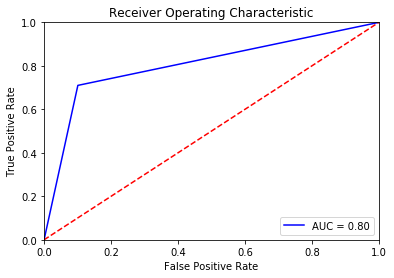

In [121]:
rfc_best_comb = {'n_estimators': 150, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'bootstrap': True}
rfc_best = RandomForestClassifier(**rfc_best_comb)
rfc_best.fit(df_clean_all, y_all)
get_prediction_precision(rfc_best, clean_x_test, clean_y_test)
plot_AUC(rfc_best)
rfc_predicts = rfc_best.predict(clean_x_test)

In [163]:
y_pred = rf_best.predict(df_test_dummy)
df_output = pd.DataFrame(data={'PassengerId': df_test['PassengerId'], 'Survived': y_pred})
df_output.to_csv("../data/processed/submission.csv", index=False)

MLP

Keras model constructed
Train on 711 samples, validate on 178 samples
Epoch 1/20000
711/711 [==============================] - 2s 3ms/step - loss: 0.6981 - acc: 0.3924 - val_loss: 0.7006 - val_acc: 0.3652
Epoch 2/20000
711/711 [==============================] - 0s 241us/step - loss: 0.6981 - acc: 0.3924 - val_loss: 0.7006 - val_acc: 0.3652
Epoch 3/20000
711/711 [==============================] - 0s 220us/step - loss: 0.6980 - acc: 0.3952 - val_loss: 0.7005 - val_acc: 0.3652
Epoch 4/20000
711/711 [==============================] - 0s 173us/step - loss: 0.6980 - acc: 0.3952 - val_loss: 0.7005 - val_acc: 0.3652
Epoch 5/20000
711/711 [==============================] - 0s 155us/step - loss: 0.6980 - acc: 0.3952 - val_loss: 0.7005 - val_acc: 0.3652
Epoch 6/20000
711/711 [==============================] - 0s 199us/step - loss: 0.6980 - acc: 0.3952 - val_loss: 0.7005 - val_acc: 0.3652
Epoch 7/20000
711/711 [==============================] - 0s 189us/step - loss: 0.6980 - acc: 0.3952 - val_loss

711/711 [==============================] - 0s 130us/step - loss: 0.6957 - acc: 0.4233 - val_loss: 0.6987 - val_acc: 0.4101
Epoch 119/20000
711/711 [==============================] - 0s 128us/step - loss: 0.6957 - acc: 0.4233 - val_loss: 0.6987 - val_acc: 0.4101
Epoch 120/20000
711/711 [==============================] - 0s 135us/step - loss: 0.6957 - acc: 0.4233 - val_loss: 0.6987 - val_acc: 0.4101
Epoch 121/20000
711/711 [==============================] - 0s 134us/step - loss: 0.6957 - acc: 0.4233 - val_loss: 0.6987 - val_acc: 0.4101
Epoch 122/20000
711/711 [==============================] - 0s 132us/step - loss: 0.6956 - acc: 0.4233 - val_loss: 0.6987 - val_acc: 0.4101
Epoch 123/20000
711/711 [==============================] - 0s 182us/step - loss: 0.6956 - acc: 0.4233 - val_loss: 0.6986 - val_acc: 0.4101
Epoch 124/20000
711/711 [==============================] - 0s 176us/step - loss: 0.6956 - acc: 0.4233 - val_loss: 0.6986 - val_acc: 0.4101
Epoch 125/20000
711/711 [==================

711/711 [==============================] - 0s 138us/step - loss: 0.6946 - acc: 0.4684 - val_loss: 0.6978 - val_acc: 0.4382
Epoch 178/20000
711/711 [==============================] - 0s 131us/step - loss: 0.6946 - acc: 0.4684 - val_loss: 0.6978 - val_acc: 0.4382
Epoch 179/20000
711/711 [==============================] - 0s 146us/step - loss: 0.6946 - acc: 0.4684 - val_loss: 0.6978 - val_acc: 0.4382
Epoch 180/20000
711/711 [==============================] - 0s 142us/step - loss: 0.6945 - acc: 0.4698 - val_loss: 0.6978 - val_acc: 0.4438
Epoch 181/20000
711/711 [==============================] - 0s 126us/step - loss: 0.6945 - acc: 0.4698 - val_loss: 0.6978 - val_acc: 0.4494
Epoch 182/20000
711/711 [==============================] - 0s 126us/step - loss: 0.6945 - acc: 0.4698 - val_loss: 0.6978 - val_acc: 0.4494
Epoch 183/20000
711/711 [==============================] - 0s 124us/step - loss: 0.6945 - acc: 0.4698 - val_loss: 0.6977 - val_acc: 0.4494
Epoch 184/20000
711/711 [==================

711/711 [==============================] - 0s 138us/step - loss: 0.6935 - acc: 0.4866 - val_loss: 0.6970 - val_acc: 0.4551
Epoch 237/20000
711/711 [==============================] - 0s 126us/step - loss: 0.6935 - acc: 0.4866 - val_loss: 0.6970 - val_acc: 0.4551
Epoch 238/20000
711/711 [==============================] - 0s 123us/step - loss: 0.6934 - acc: 0.4866 - val_loss: 0.6970 - val_acc: 0.4551
Epoch 239/20000
711/711 [==============================] - 0s 127us/step - loss: 0.6934 - acc: 0.4866 - val_loss: 0.6969 - val_acc: 0.4551
Epoch 240/20000
711/711 [==============================] - 0s 137us/step - loss: 0.6934 - acc: 0.4866 - val_loss: 0.6969 - val_acc: 0.4551
Epoch 241/20000
711/711 [==============================] - 0s 133us/step - loss: 0.6934 - acc: 0.4866 - val_loss: 0.6969 - val_acc: 0.4551
Epoch 242/20000
711/711 [==============================] - 0s 128us/step - loss: 0.6934 - acc: 0.4866 - val_loss: 0.6969 - val_acc: 0.4607
Epoch 243/20000
711/711 [==================

711/711 [==============================] - 0s 128us/step - loss: 0.6924 - acc: 0.4993 - val_loss: 0.6962 - val_acc: 0.5000
Epoch 296/20000
711/711 [==============================] - 0s 152us/step - loss: 0.6924 - acc: 0.4993 - val_loss: 0.6961 - val_acc: 0.5000
Epoch 297/20000
711/711 [==============================] - 0s 154us/step - loss: 0.6924 - acc: 0.4993 - val_loss: 0.6961 - val_acc: 0.5000
Epoch 298/20000
711/711 [==============================] - 0s 139us/step - loss: 0.6923 - acc: 0.4993 - val_loss: 0.6961 - val_acc: 0.5000
Epoch 299/20000
711/711 [==============================] - 0s 119us/step - loss: 0.6923 - acc: 0.4993 - val_loss: 0.6961 - val_acc: 0.5000
Epoch 300/20000
711/711 [==============================] - 0s 123us/step - loss: 0.6923 - acc: 0.4993 - val_loss: 0.6961 - val_acc: 0.5000
Epoch 301/20000
711/711 [==============================] - 0s 126us/step - loss: 0.6923 - acc: 0.4993 - val_loss: 0.6961 - val_acc: 0.5000
Epoch 302/20000
711/711 [==================

...

711/711 [==============================] - 0s 126us/step - loss: 0.4650 - acc: 0.8256 - val_loss: 0.5768 - val_acc: 0.7247
Epoch 11792/20000
711/711 [==============================] - 0s 125us/step - loss: 0.4650 - acc: 0.8256 - val_loss: 0.5768 - val_acc: 0.7247
Epoch 11793/20000
711/711 [==============================] - 0s 130us/step - loss: 0.4650 - acc: 0.8256 - val_loss: 0.5768 - val_acc: 0.7247
Epoch 11794/20000
711/711 [==============================] - 0s 127us/step - loss: 0.4650 - acc: 0.8256 - val_loss: 0.5768 - val_acc: 0.7247
Epoch 11795/20000
711/711 [==============================] - 0s 128us/step - loss: 0.4650 - acc: 0.8256 - val_loss: 0.5768 - val_acc: 0.7247
Epoch 11796/20000
711/711 [==============================] - 0s 125us/step - loss: 0.4649 - acc: 0.8256 - val_loss: 0.5767 - val_acc: 0.7247
Epoch 11797/20000
711/711 [==============================] - 0s 126us/step - loss: 0.4649 - acc: 0.8256 - val_loss: 0.5767 - val_acc: 0.7247
Epoch 11798/20000
711/711 [====

711/711 [==============================] - 0s 128us/step - loss: 0.4628 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11908/20000
711/711 [==============================] - 0s 137us/step - loss: 0.4628 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11909/20000
711/711 [==============================] - 0s 139us/step - loss: 0.4628 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11910/20000
711/711 [==============================] - 0s 133us/step - loss: 0.4628 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11911/20000
711/711 [==============================] - 0s 130us/step - loss: 0.4628 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11912/20000
711/711 [==============================] - 0s 128us/step - loss: 0.4627 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11913/20000
711/711 [==============================] - 0s 131us/step - loss: 0.4627 - acc: 0.8256 - val_loss: 0.5765 - val_acc: 0.7191
Epoch 11914/20000
711/711 [====

711/711 [==============================] - 0s 127us/step - loss: 0.4607 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12024/20000
711/711 [==============================] - 0s 127us/step - loss: 0.4607 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12025/20000
711/711 [==============================] - 0s 126us/step - loss: 0.4606 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12026/20000
711/711 [==============================] - 0s 125us/step - loss: 0.4606 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12027/20000
711/711 [==============================] - 0s 125us/step - loss: 0.4606 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12028/20000
711/711 [==============================] - 0s 128us/step - loss: 0.4606 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12029/20000
711/711 [==============================] - 0s 127us/step - loss: 0.4606 - acc: 0.8256 - val_loss: 0.5762 - val_acc: 0.7191
Epoch 12030/20000
711/711 [====

711/711 [==============================] - 0s 131us/step - loss: 0.4586 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12140/20000
711/711 [==============================] - 0s 127us/step - loss: 0.4585 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12141/20000
711/711 [==============================] - 0s 134us/step - loss: 0.4585 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12142/20000
711/711 [==============================] - 0s 128us/step - loss: 0.4585 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12143/20000
711/711 [==============================] - 0s 131us/step - loss: 0.4585 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12144/20000
711/711 [==============================] - 0s 130us/step - loss: 0.4585 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12145/20000
711/711 [==============================] - 0s 128us/step - loss: 0.4584 - acc: 0.8256 - val_loss: 0.5760 - val_acc: 0.7191
Epoch 12146/20000
711/711 [====

711/711 [==============================] - 0s 127us/step - loss: 0.4564 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12256/20000
711/711 [==============================] - 0s 126us/step - loss: 0.4564 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12257/20000
711/711 [==============================] - 0s 125us/step - loss: 0.4564 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12258/20000
711/711 [==============================] - 0s 125us/step - loss: 0.4564 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12259/20000
711/711 [==============================] - 0s 126us/step - loss: 0.4564 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12260/20000
711/711 [==============================] - 0s 124us/step - loss: 0.4563 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12261/20000
711/711 [==============================] - 0s 126us/step - loss: 0.4563 - acc: 0.8256 - val_loss: 0.5759 - val_acc: 0.7191
Epoch 12262/20000
711/711 [====

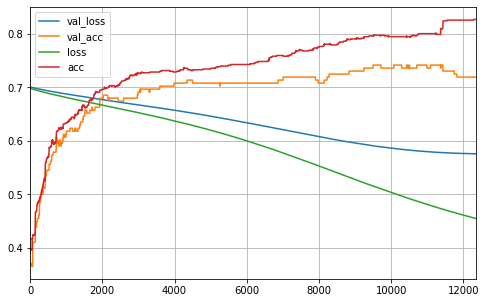

In [21]:
def create_keras_model(optimizer='adam', neuron=50, init='lecun_normal', act_alpha=0.01):
    model_sequences = [
        keras.layers.Dense(units=neuron, kernel_initializer=init, 
                           #activation='relu',
                           input_shape=x_training_normed.shape[1:]
                          ),
        
        keras.layers.LeakyReLU(alpha=act_alpha)
    ]

    for i in range(5):
        model_sequences.append(keras.layers.Dense(units=neuron, kernel_initializer=init,
                                                  #activation='relu',
                                                  input_shape=x_training_normed.shape[1:]))
        model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    #model_sequences.append(keras.layers.BatchNormalization())
    model_sequences.append(Dense(units=1, name='score_output',
                                 activation='sigmoid'
                                ))
    #model_sequences.append(keras.layers.LeakyReLU(alpha=act_alpha))

    nn_model = keras.models.Sequential(model_sequences)
    nn_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return nn_model

optimizer = keras.optimizers.Adadelta(lr=1e-4)
nn_model = create_keras_model(optimizer=optimizer, neuron=100, init='lecun_uniform', act_alpha=0.05)
print("Keras model constructed")
early_stopping_cb = EarlyStopping(patience=20)
history = nn_model.fit(x_training_normed, y_training_normed, validation_data=(x_test_normed, y_test_normed), epochs=20000, callbacks=[early_stopping_cb], verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [23]:
print(x_training_normed.shape)
nn_model.summary()

(711, 163)
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_58 (Dense)             (None, 100)               16400     
_________________________________________________________________
leaky_re_lu_15 (LeakyReLU)   (None, 100)               0         
_________________________________________________________________
dense_59 (Dense)             (None, 100)               10100     
_________________________________________________________________
leaky_re_lu_16 (LeakyReLU)   (None, 100)               0         
_________________________________________________________________
dense_60 (Dense)             (None, 100)               10100     
_________________________________________________________________
leaky_re_lu_17 (LeakyReLU)   (None, 100)               0         
_________________________________________________________________
dense_61 (Dense)             (None, 100)               10100     

In [136]:
def plot_AUC(model):
    preds = model.predict(x_test_normed)
    fpr, tpr, threshold = roc_curve(y_test_normed, preds)
    roc_auc = auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label='AUC = %0.2f' % roc_auc)
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

XGBoost

In [134]:
xgb_param_grid = {"objective" : ['binary:logistic', 'binary:hinge'],
                  "n_estimators": [50, 100, 150],
                  "base_score" : [0.03, 0.04, 0.05],
                  "max_depth": [3, 4, 5],
                  "gamma": [0.05, 0.1, 0.2],
                  "min_child_weight": range(1, 6, 2)
                 }
xgb_best_comb, _ = GridSearchWithVal(xgboost.XGBClassifier, xgb_param_grid)

486 combinations in total
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 3, 

{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.05, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.1, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.1, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 50, 'base_score': 0.05, 'max_depth': 5, 'gamma': 0.05, 'min_child_we

{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.04, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.04, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.04, 'max_depth': 5, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.04, 'max_depth': 5, 'gamma': 0.2, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.04, 'max_depth': 5, 'gamma': 0.2, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.05, 'min

{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 4, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 4, 'gamma': 0.05, 'min_child_weight': 3}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 4, 'gamma': 0.05, 'min_child_weight': 5}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 4, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:logistic', 'n_estimators': 150, 'base_score': 0.04, 'max_depth': 4, 'gamma': 0.1, 'min

{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.05, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.05, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 50, 'base_score': 0.03, 'max_depth': 5, 'gamma': 0.2, 'min_child_weight': 1}
{'objective':

{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 4, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.03, 'max_depth': 4, 'gamma': 0.05, 'min_child_weight': 3}
{'obje

{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 4, 'gamma': 0.2, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 5, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 5, 'gamma': 0.05, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 5, 'gamma': 0.05, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 100, 'base_score': 0.05, 'max_depth': 5, 'gamma': 0.1, 'min_child_weight': 3}
{'obj

{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.05, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 3}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.1, 'min_child_weight': 5}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 1}
{'objective': 'binary:hinge', 'n_estimators': 150, 'base_score': 0.05, 'max_depth': 3, 'gamma': 0.2, 'min_child_weight': 3}
{'obj

begin training XGBoost...
training finished, get predictions...
n_correct:148
accuracy: 0.8314606741573034


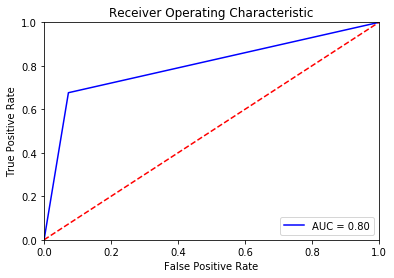

In [137]:
xgb_best = xgboost.XGBClassifier(**xgb_best_comb)
print("begin training XGBoost...")
xgb_best.fit(df_train_normed, y_all, verbose=True)
print("training finished, get predictions...")
#dump(xgb_clf, '../models/xgb.joblib')
get_prediction_precision(xgb_best, x_test_normed, y_test_normed)
#print("score: {}".format(xgb_best.score(X_test, y_test)))
plot_AUC(xgb_best)
xgb_predicts = xgb_best.predict(x_test_normed)

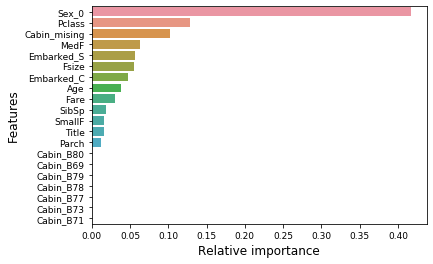

In [493]:
xgb_clf.feature_importances_

def plot_feature_importance(model):
    indices = np.argsort(model.feature_importances_)[::-1][:20]
    g = sns.barplot(y=X_training.columns[indices][:40],x = model.feature_importances_[indices][:40] , orient='h')
    g.set_xlabel("Relative importance",fontsize=12)
    g.set_ylabel("Features",fontsize=12)
    g.tick_params(labelsize=9)
    
plot_feature_importance(xgb_clf)

Gradient Boosting Classifier

In [138]:
gb_param_grid = {"n_estimators" : [50, 100, 150, 200, 250],
                  "loss" : ["deviance"],
                  "learning_rate": [0.03, 0.04, 0.05, 0.06, 0.08, 0.1],
                  "max_depth": [4, 5, 6, 7],
                  "min_samples_leaf": [50, 100, 120],
                  "max_features": [0.3, 0.1, None] 
                }
gbc_best_param, _ = GridSearchWithVal(GradientBoostingClassifier, gb_param_grid)

1080 combinations in total
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples

{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 50, 'max_feature

{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features'

{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 50, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.3}

{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 100, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 100, 'max_f

...

{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 120, 'max_

{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 200, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 50, 'max_featur

{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 6, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.04, 'max_depth': 7, 'min_samples_leaf': 100, 'max_

{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.06, 'max_depth': 6, 'min_samples_leaf': 100, 'max_f

{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 50, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': 0.1}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 100, 'max_features': None}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features': 0.3}
{'n_estimators': 250, 'loss': 'deviance', 'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 120, 'max_features'

n_correct:141
accuracy: 0.7921348314606742


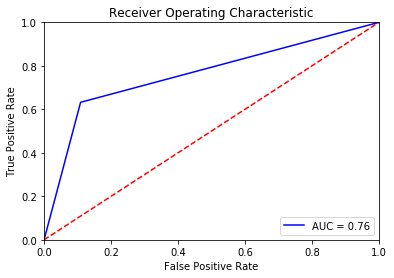

In [139]:
GB_best = GradientBoostingClassifier(**gbc_best_param)
GB_best.fit(df_train_normed, y_all)
get_prediction_precision(GB_best, x_test_normed, y_test_normed)
plot_AUC(GB_best)
gb_predicts = GB_best.predict(x_test_normed)
#plot_feature_importance(GB_clf)

AdaBoost Classifier with Decision Tree

In [140]:
gdtc = DecisionTreeClassifier()
adaDTC = AdaBoostClassifier(gdtc, random_state=17)
gb_param_grid = {"algorithm" : ["SAMME","SAMME.R"],
                 "n_estimators" :[200, 250, 280, 300, 350],
                 "learning_rate":  [0.03, 0.04, 0.05, 0.06, 0.07]
                }
sub_param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [3, 4, 5, None],
    "min_samples_split": [1.0, 2,3,4]
}

gdt_best_params, dt_best_params = GridSearchWithVal(AdaBoostClassifier, gb_param_grid, DecisionTreeClassifier, sub_param_grid)

50 combinations in total
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.03}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.04}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.05}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.06}
{'algorithm': 'SAMME', 'n_estimators': 200, 'learning_rate': 0.07}
{'algorithm': 'SAMME', 'n_estimators': 250, 'learning_rate': 0.03}
{'algorithm': 'SAMME', 'n_estimators': 250, 'learning_rate': 0.04}
{'algorithm': 'SAMME', 'n_estimators': 250, 'learning_rate': 0.05}
{'algorithm': 'SAMME', 'n_estimators': 250, 'learning_rate': 0.06}
{'algorithm': 'SAMME', 'n_estimators': 250, 'learning_rate': 0.07}
{'algorithm': 'SAMME', 'n_estimators': 280, 'learning_rate': 0.03}
{'algorithm': 'SAMME', 'n_estimators': 280, 'learning_rate': 0.04}
{'algorithm': 'SAMME', 'n_estimators': 280, 'learning_rate': 0.05}
{'algorithm': 'SAMME', 'n_estimators': 280, 'learning_rate': 0.06}
{'algorithm': 'SAMME', 'n_estimators'

n_correct:142
accuracy: 0.797752808988764


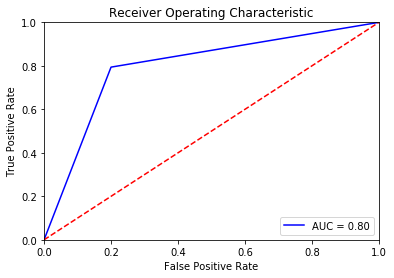

In [141]:
dtc = DecisionTreeClassifier(**dt_best_params)
adb_best = AdaBoostClassifier(base_estimator=dtc, **gdt_best_params)
adb_best.fit(df_clean_all, y_all)
get_prediction_precision(adb_best, x_test_normed, y_test_normed)
plot_AUC(adb_best)
adb_predicts = adb_best.predict(x_test_normed)
#plot_feature_importance(adb_best)

SVM

In [112]:
svm_param_grid = {'kernel': ['rbf'], 
                  'probability': [True],
                  'gamma': [ 0.001, 0.01, 0.1, 1],
                  'C': [1, 10, 50, 100,200,300, 1000]
                }
svm_best_param, _ = GridSearchWithVal(SVC, svm_param_grid)

28 combinations in total
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 1}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 10}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 50}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 100}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 200}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 300}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.001, 'C': 1000}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 1}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 10}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 50}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 100}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 200}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 300}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.01, 'C': 1000}
{'kernel': 'rbf', 'probability': True, 'gamma': 0.1, 'C': 1}
{'kernel': 'rbf',

n_correct:615
accuracy: 0.8649789029535865


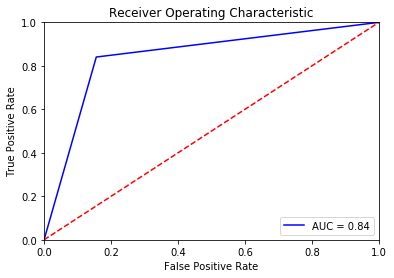

In [118]:
svm_best = SVC(**svm_best_param)
svm_best.fit(df_clean_all, y_all)
get_prediction_precision(svm_best, clean_x_training, clean_y_training)
plot_AUC(svm_best)
svm_predicts = svm_best.predict(clean_x_test)

n_correct:156
accuracy: 0.8764044943820225


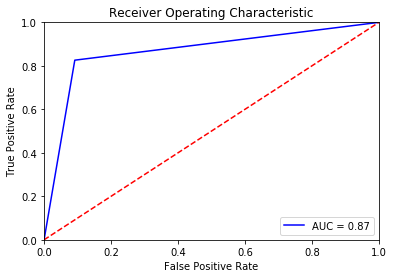

In [127]:
voting_clf = VotingClassifier(estimators=[
    ('rfc', rfc_best), ('xgb', xgbc_best), ('gbc', gbc_best), ('adb', adbc_best), ('svm', svm_best)], voting='soft')
voting_clf = voting_clf.fit(df_clean_all, y_all)
get_prediction_precision(voting_clf, clean_x_test, clean_y_test)
plot_AUC(voting_clf)
#plot_feature_importance(voting_clf)

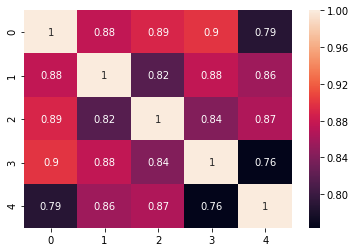

In [124]:
ensemble_results = pd.concat([pd.Series(rfc_predicts), pd.Series(xgb_predicts), pd.Series(gb_predicts),
                              pd.Series(adb_predicts), pd.Series(svm_predicts)], axis=1)
g= sns.heatmap(ensemble_results.corr(),annot=True)

In [128]:
df_test = pd.read_csv("../data/raw/test.csv")

df_test['Cabin'].fillna('mising', inplace=True)
df_test['Age'].fillna(df['Age'].mean(), inplace=True)
df_test['Fare'].fillna(df['Fare'].mean(), inplace=True)
df_test['Embarked'].fillna(df['Embarked'].mode(), inplace=True)
df_test.isna().sum()

passenger_ids = df_test['PassengerId']
columns_to_remove = ['PassengerId', 'Ticket']
df_test.drop(columns=columns_to_remove, inplace=True)

nd_title_test = [i.split(",")[1].split(".")[0].strip() for i in df_test["Name"]]
df_test["Title"] = pd.Series(nd_title_test)
df_test["Title"] = df_test["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', math.nan], 'Rare')
df_test["Title"] = df_test["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
df_test["Title"] = df_test["Title"].astype(int)
df_test["Fsize"] = df_test["SibSp"] + df_test["Parch"] + 1
df_test['Single'] = df_test['Fsize'].map(lambda s: 1 if s == 1 else 0)
df_test['SmallF'] = df_test['Fsize'].map(lambda s: 1 if  s == 2  else 0)
df_test['MedF'] = df_test['Fsize'].map(lambda s: 1 if 3 <= s <= 4 else 0)
df_test['LargeF'] = df_test['Fsize'].map(lambda s: 1 if s >= 5 else 0)
df_test.drop(columns=['Name'], inplace=True)

# Create new feature IsAlone from FamilySize
df_test['IsAlone'] = 0
df_test.loc[df_test['Fsize'] == 1, 'IsAlone'] = 1
# Create new feature CategoricalFare
df_test['CategoricalFare'] = pd.qcut(df_test['Fare'], 4)
df_test.loc[df_test['Fare'] <= 7.91, 'Fare'] = 0
df_test.loc[(df_test['Fare'] > 7.91) & (df_test['Fare'] <= 14.454), 'Fare'] = 1
df_test.loc[(df_test['Fare'] > 14.454) & (df_test['Fare'] <= 31), 'Fare']   = 2
df_test.loc[df_test['Fare'] > 31, 'Fare'] = 3
df_test['Fare'] = df_test['Fare'].astype(int)
df_test['Sex'] = df_test['Sex'].map( {'female': 0, 'male': 1} ).astype(int)
# Create new feature CategoricalAge
df_test['CategoricalAge'] = pd.cut(df_test['Age'], 5)
df_test.loc[df_test['Age'] <= 16, 'Age'] = 0
df_test.loc[(df_test['Age'] > 16) & (df_test['Age'] <= 32), 'Age'] = 1
df_test.loc[(df_test['Age'] > 32) & (df_test['Age'] <= 48), 'Age'] = 2
df_test.loc[(df_test['Age'] > 48) & (df_test['Age'] <= 64), 'Age'] = 3
df_test.loc[df_test['Age'] > 64, 'Age'] = 4 
df_test.drop(columns=['CategoricalAge', 'CategoricalFare'], inplace=True)


test_final_columns = list(df_clean.columns)
test_final_columns.remove(y_label)
df_test_dummy = pd.DataFrame(columns=test_final_columns)
for idx, row in df_test.iterrows():
    series_dict = {}
    for col in test_final_columns:
        if '_' in col:
            ctg_name, ctg_value = col.split('_')
            series_dict[col] = 1 if row[ctg_name] == ctg_value else 0
        else:
            series_dict[col] = row[col]
    df_test_dummy= df_test_dummy.append(series_dict, ignore_index=True)


#df_test_dummy[column_to_nmlz] = num_pipeline.fit_transform(df_test_dummy[column_to_nmlz])
df_test_dummy

,Pclass,Sex,Age,SibSp,Parch,Fare,Title,Fsize,Single,SmallF,...,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_mising
0,3.0,1.0,2.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3.0,0.0,2.0,1.0,0.0,0.0,1.0,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2.0,1.0,3.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.0,1.0,1.0,1.0,1.0,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
414,1.0,0.0,2.0,0.0,0.0,3.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
415,3.0,1.0,2.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
416,3.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [129]:
y_pred_9 = voting_clf.predict(df_test_dummy)
df_output_9 = pd.DataFrame(data={'PassengerId': passenger_ids, 'Survived': y_pred_9})
df_output_9
df_output_9.to_csv("../data/processed/submission_9.csv", index=False)

In [91]:
y_pred_6 = adb_best.predict(df_test_dummy)
df_output_6 = pd.DataFrame(data={'PassengerId': passenger_ids, 'Survived': y_pred_6})
df_output_6
df_output_6.to_csv("../data/processed/submission_6.csv", index=False)

In [95]:
adb_best

AdaBoostClassifier(algorithm='SAMME.R',
                   base_estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                                         class_weight=None,
                                                         criterion='gini',
                                                         max_depth=None,
                                                         max_features=None,
                                                         max_leaf_nodes=None,
                                                         min_impurity_decrease=0.0,
                                                         min_impurity_split=None,
                                                         min_samples_leaf=1,
                                                         min_samples_split=2,
                                                         min_weight_fraction_leaf=0.0,
                                                         presort='deprecated',
                       